#Customer Churn Analysis | EDA, Leakage Investigation & ML Comparison

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('eda_plots', exist_ok=True)

In [ ]:
df1 = pd.read_csv('customer_churn.csv')

In [ ]:
df = df1.copy()

In [ ]:
df.shape

(440833, 12)

In [ ]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [ ]:
df.sample(5)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
234902,241237.0,22.0,Female,42.0,14.0,8.0,5.0,Basic,Quarterly,456.09,8.0,1.0
114611,118211.0,37.0,Female,36.0,25.0,1.0,9.0,Premium,Monthly,412.00,13.0,1.0
383658,390773.0,27.0,Male,55.0,24.0,0.0,2.0,Basic,Quarterly,681.54,14.0,0.0
237562,244012.0,23.0,Female,51.0,3.0,7.0,16.0,Standard,Monthly,331.13,24.0,1.0
106718,109974.0,42.0,Female,27.0,22.0,4.0,9.0,Standard,Annual,815.00,29.0,1.0


# Initial Data Assessment
## Issues Found with the dataset

### 1. Dirty Data
- The data type of CustomerID, Age,Tenure,Usage Frequency , Support Calls , Payment Delay should be integer but it have been encoded as float
- several variables that represent whole-number counts or binary values were stored as float64

### 2. Messy Data

- one completely empty row was found in the dataset. The row contained missing values across all columns and therefore did not provide any useful customer information.

### 3. Feature Selection
- The CustomerID is not a predictive feature. We may drop this column (CustomerID will be excluded from the features used for model training.)

In [ ]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [ ]:
df.sample(5)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
362518,369633.0,36.0,Female,45.0,8.0,2.0,6.0,Basic,Annual,728.72,3.0,0.0
134064,138504.0,60.0,Female,14.0,15.0,2.0,24.0,Premium,Annual,169.00,10.0,1.0
617,626.0,27.0,Female,42.0,27.0,10.0,20.0,Premium,Monthly,591.00,26.0,1.0
354915,362030.0,40.0,Male,18.0,25.0,1.0,1.0,Standard,Quarterly,978.00,13.0,0.0
391664,398779.0,29.0,Male,31.0,25.0,2.0,3.0,Standard,Annual,856.72,13.0,0.0


In [ ]:
df.shape

(440833, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


CustomerID has decimals  - this suggests it might have been accidentally encoded as float. CustomerID should be an integer or dropped entirely.

Age and some other features are also showing as floats.
We have to fix these data types



In [ ]:
df.columns.tolist()

['CustomerID',
 'Age',
 'Gender',
 'Tenure',
 'Usage Frequency',
 'Support Calls',
 'Payment Delay',
 'Subscription Type',
 'Contract Length',
 'Total Spend',
 'Last Interaction',
 'Churn']

In [ ]:
df.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [ ]:
df[df.isna().all(axis=1)]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In row 199295, All values are missing. We may drop this row

In [ ]:
df.isna().all(axis=1).sum()

np.int64(1)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
CustomerID,440832
Age,48
Gender,2
Tenure,60
Usage Frequency,30
Support Calls,11
Payment Delay,31
Subscription Type,3
Contract Length,3
Total Spend,68363


In [ ]:
for col in df.select_dtypes(include='object'):
    print(f"\n{col}:")
    print(df[col].value_counts())


Gender:
Gender
Male      250252
Female    190580
Name: count, dtype: int64

Subscription Type:
Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

Contract Length:
Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,440832.0,225398.667955,129531.918550,2.0,113621.75,226125.5,337739.25,449999.0
Age,440832.0,39.373153,12.442369,18.0,29.00,39.0,48.00,65.0
Tenure,440832.0,31.256336,17.255727,1.0,16.00,32.0,46.00,60.0
Usage Frequency,440832.0,15.807494,8.586242,1.0,9.00,16.0,23.00,30.0
Support Calls,440832.0,3.604437,3.070218,0.0,1.00,3.0,6.00,10.0
Payment Delay,440832.0,12.965722,8.258063,0.0,6.00,12.0,19.00,30.0
Total Spend,440832.0,631.616223,240.803001,100.0,480.00,661.0,830.00,1000.0
Last Interaction,440832.0,14.480868,8.596208,1.0,7.00,14.0,22.00,30.0
Churn,440832.0,0.567107,0.495477,0.0,0.00,1.0,1.00,1.0


In [ ]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
1.0,56.71072
0.0,43.28928


In [ ]:
df.dtypes

,0
CustomerID,float64
Age,float64
Gender,object
Tenure,float64
Usage Frequency,float64
Support Calls,float64
Payment Delay,float64
Subscription Type,object
Contract Length,object
Total Spend,float64


# Data Cleaning

**Issue:** one completely empty row was found in the dataset. The row contained missing values across all columns and therefore did not provide any useful customer information.

**Cleaning action:** Removed the completely empty row because it contained no customer information.

In [ ]:
df = df.dropna(how='all').reset_index(drop=True)

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [ ]:
df.shape

(440832, 12)

**Issue:** The data type of CustomerID, Age,Tenure,Usage Frequency , Support Calls , Payment Delay should be integer but it have been encoded as float and several variables that represent whole-number counts or binary values were stored as float64

**Cleaning action:** Converted CustomerID, Age, Tenure, Usage Frequency, Support Calls, Payment Delay, and Last Interaction to integer type. Churn was also converted to integer because it is a binary variable.

In [ ]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [ ]:
# Integer columns
int_cols = ['CustomerID','Age','Tenure','Usage Frequency','Support Calls','Payment Delay','Last Interaction','Churn']

df[int_cols] = df[int_cols].astype('int64')

# Categorical columns
cat_cols = ['Gender','Subscription Type','Contract Length']

df[cat_cols] = df[cat_cols].astype('category')


In [ ]:
df.dtypes

,0
CustomerID,int64
Age,int64
Gender,category
Tenure,int64
Usage Frequency,int64
Support Calls,int64
Payment Delay,int64
Subscription Type,category
Contract Length,category
Total Spend,float64


# EDA

In [ ]:
df.sample(5)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
184530,189341,52,Female,34,26,8,8,Standard,Annual,495.00,8,1
54842,55836,44,Female,7,11,6,16,Premium,Monthly,699.00,2,1
184069,188880,54,Male,27,27,4,22,Premium,Quarterly,975.00,20,1
9527,9536,33,Male,15,9,6,8,Standard,Monthly,742.00,24,1
255271,262386,37,Male,36,2,3,17,Premium,Annual,619.15,16,0


In [ ]:
num_cols = [
    'Age',
    'Tenure',
    'Usage Frequency',
    'Payment Delay',
    'Total Spend',
    'Last Interaction'
]

cat_cols = [
    'Gender',
    'Support Calls',
    'Subscription Type',
    'Contract Length'
]

target = 'Churn'

## Target variable analysis

- The target variable is slightly imbalanced

In [ ]:
df[target].value_counts()

,count
Churn,
1,249999
0,190833


In [ ]:
df[target].value_counts(normalize=True)*100

,proportion
Churn,
1,56.71072
0,43.28928


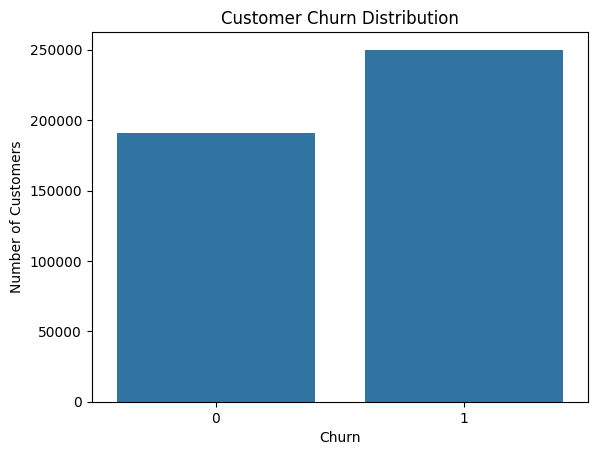

In [ ]:
sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

## Univariate Analysis


### Numerical columns
 - everything is fine in numerical columns

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Tenure'}>],
       [<Axes: title={'center': 'Usage Frequency'}>,
        <Axes: title={'center': 'Payment Delay'}>],
       [<Axes: title={'center': 'Total Spend'}>,
        <Axes: title={'center': 'Last Interaction'}>]], dtype=object)

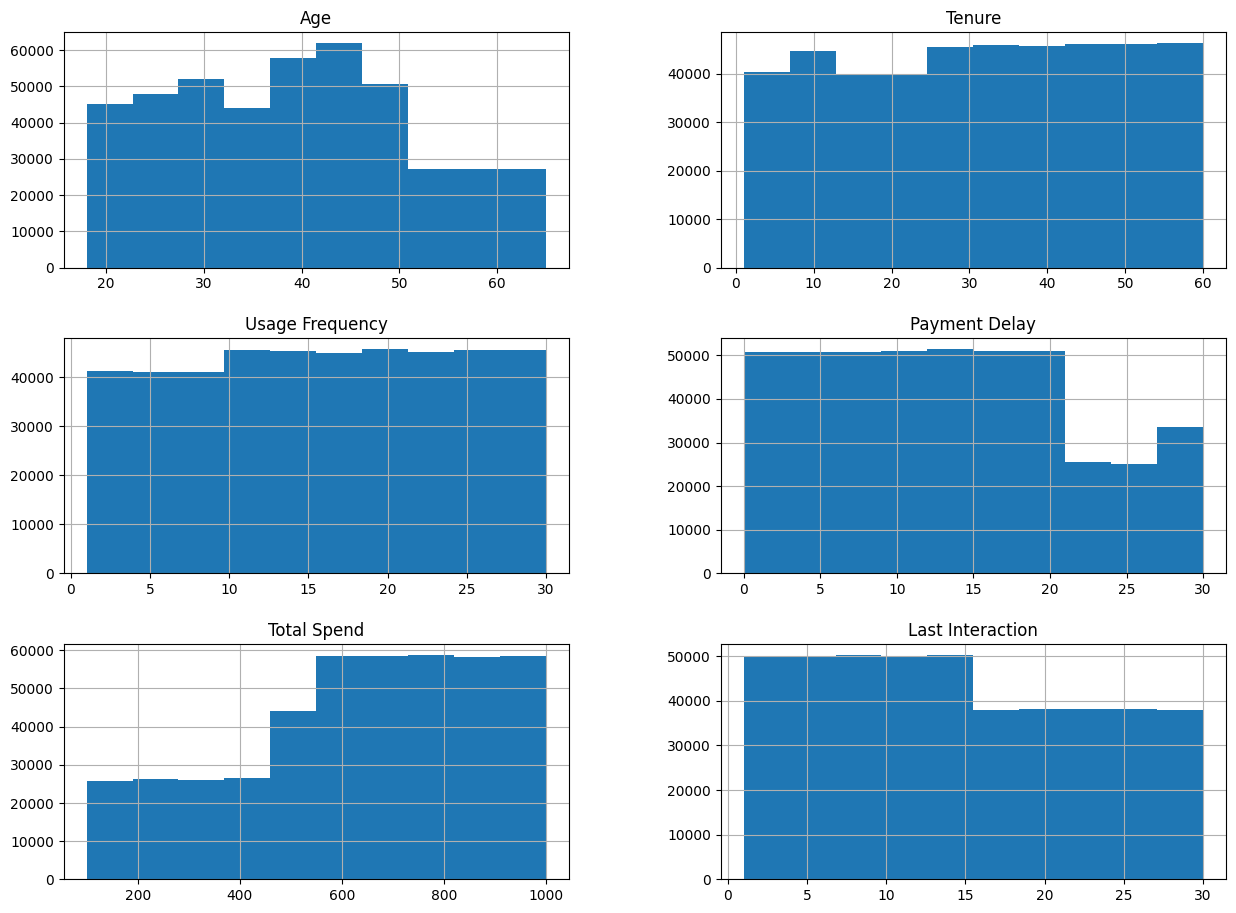

In [ ]:
df[num_cols].hist(figsize=(15,11))

In [ ]:
df[num_cols].skew().sort_values(ascending=False)

,0
Payment Delay,0.267407
Last Interaction,0.176774
Age,0.162016
Usage Frequency,-0.043473
Tenure,-0.061402
Total Spend,-0.457174


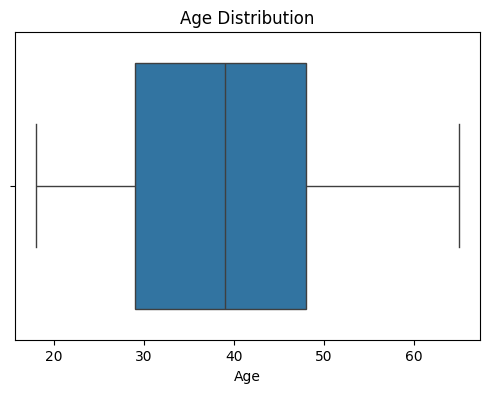

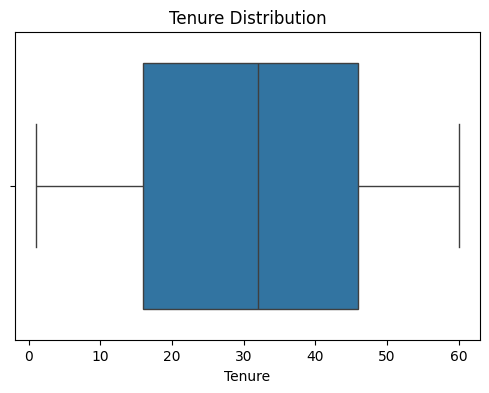

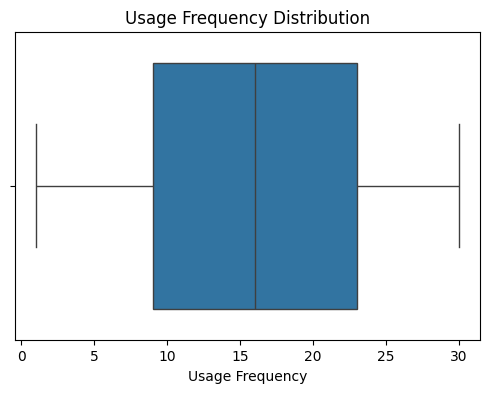

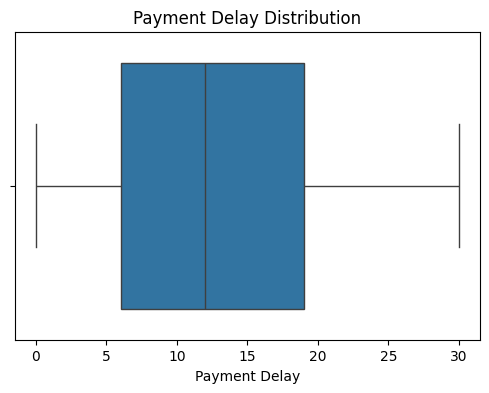

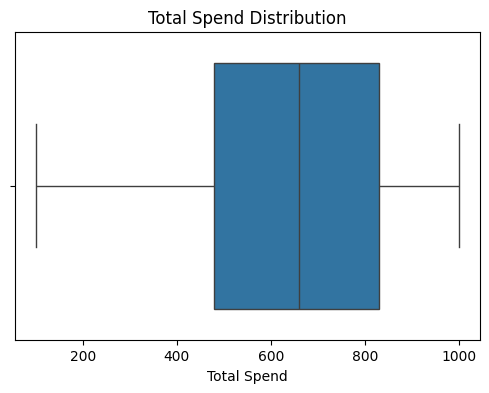

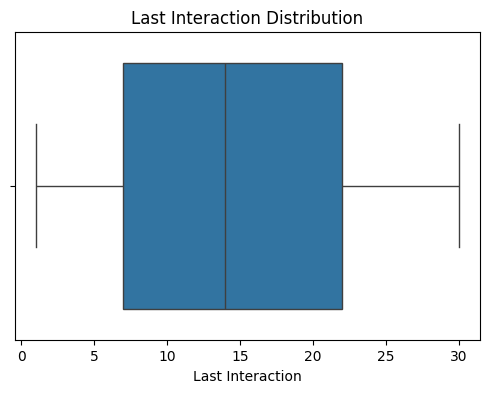

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f'{col} Distribution')
    plt.show()

### Categorical Columns

- Monthly contracts account for only 19.8% of customers.Annual and Quarterly contracts together account for approximately 80.2% of customers.The distribution is therefore concentrated in Annual and Quarterly contracts.

In [ ]:
for col in cat_cols:
    print('-'*100)
    print(df[col].value_counts())

----------------------------------------------------------------------------------------------------
Gender
Male      250252
Female    190580
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Support Calls
0     69875
1     69476
2     66571
3     52729
4     38750
5     24918
10    23900
7     23870
9     23630
8     23559
6     23554
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64


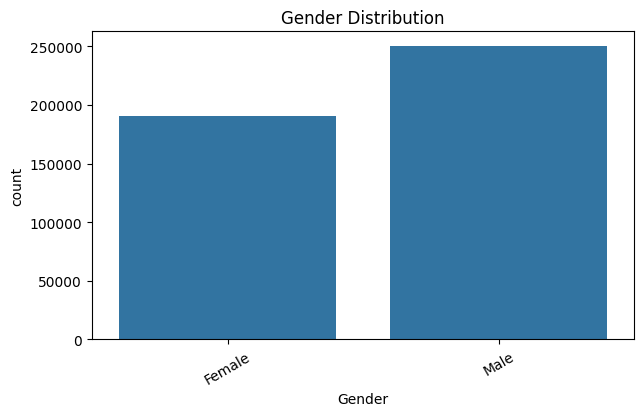

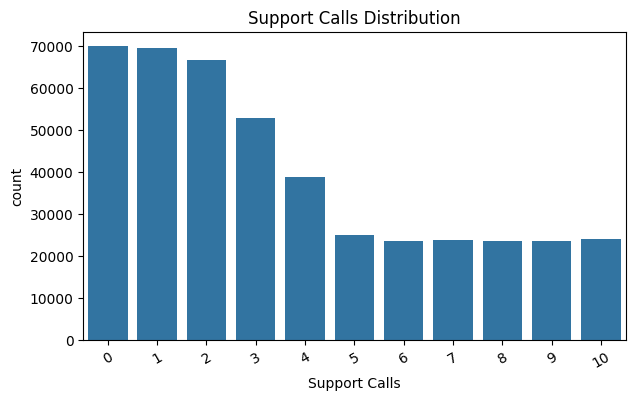

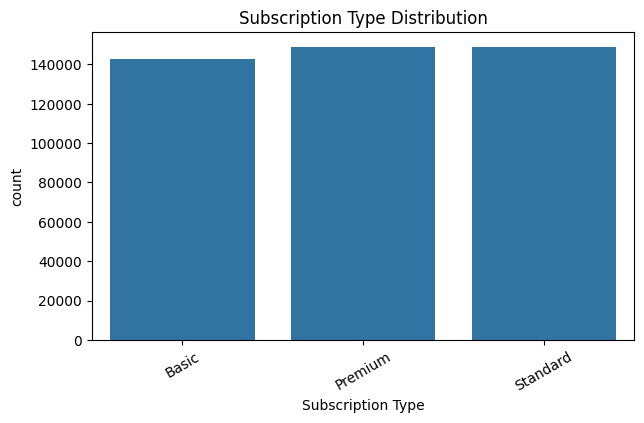

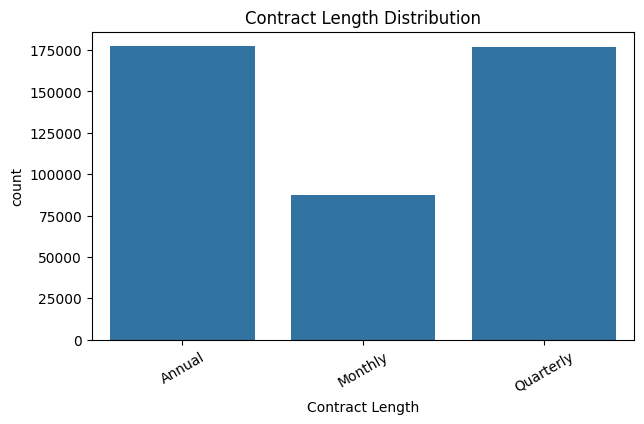

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=30)
    plt.show()

## Bivariate Analysis

### Numerical variables vs Target
- All numerical features are significant
  

In [ ]:
for col in num_cols:
    churned = df[df['Churn'] == 1][col]
    retained = df[df['Churn'] == 0][col]
    t_stat, p_value = stats.ttest_ind(churned, retained)
    print(f"{col:20s} | p-value: {p_value:.6f} | {'SIGNIFICANT' if p_value < 0.05 else 'NOT SIGNIFICANT'}")

Age                  | p-value: 0.000000 | SIGNIFICANT
Tenure               | p-value: 0.000000 | SIGNIFICANT
Usage Frequency      | p-value: 0.000000 | SIGNIFICANT
Payment Delay        | p-value: 0.000000 | SIGNIFICANT
Total Spend          | p-value: 0.000000 | SIGNIFICANT
Last Interaction     | p-value: 0.000000 | SIGNIFICANT


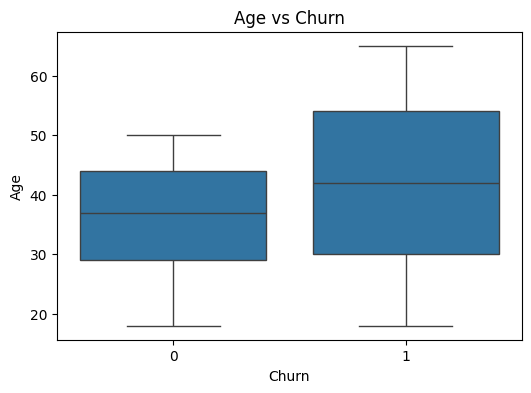

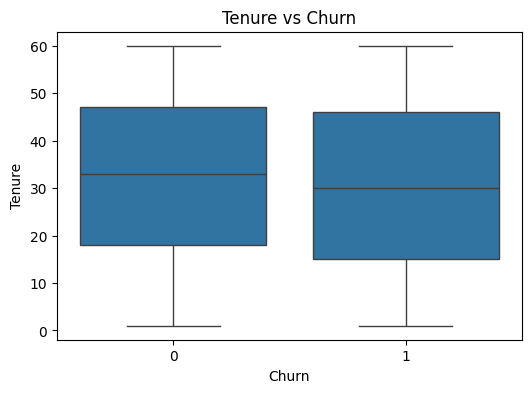

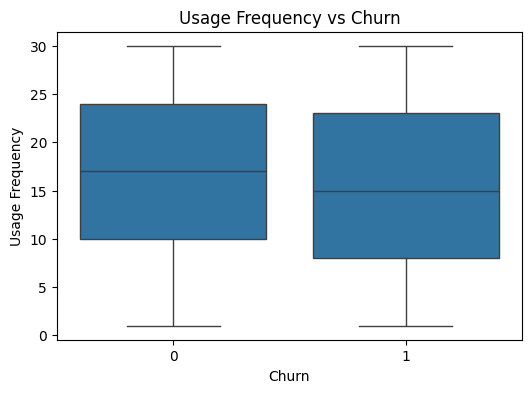

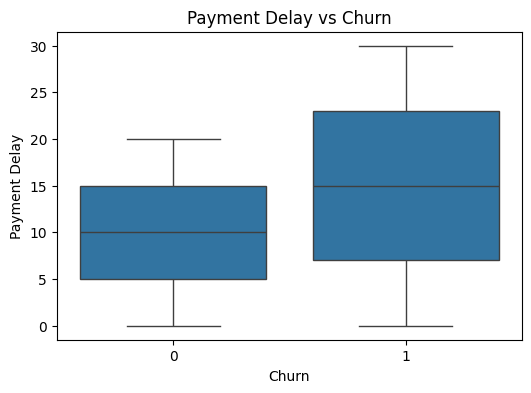

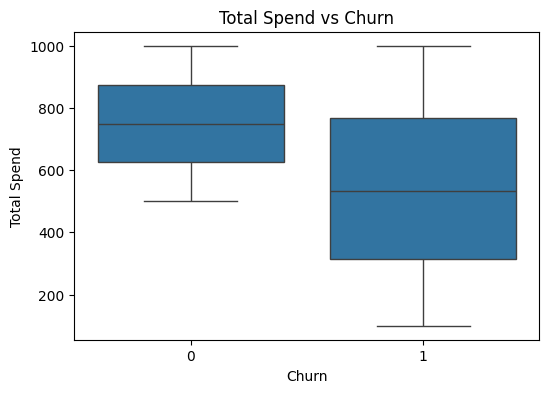

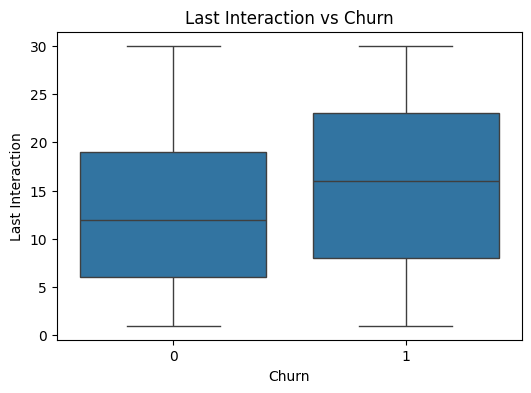

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x='Churn', y=col)
    plt.title(f'{col} vs Churn')
    plt.show()

### Categoriacl vs Target
- **Gender vs Churn:** Female customers have a higher churn rate (66.67%) compared with male customers (49.13%), representing a difference of approximately 17.5 percentage points. This suggests a potential association between gender and churn that may warrant further investigation.
- **Subscription Type vs Churn:** Churn rates are relatively similar across subscription types. Basic customers have the highest observed churn rate (58.18%), while Premium customers have the lowest (55.94%). The relatively small difference suggests that subscription type alone may have a limited association with churn.
- **Contract Length vs Churn:** Annual and Quarterly customers have very similar churn rates of approximately 46%. In contrast, Monthly customers have an observed churn rate of 100%. This represents a highly unusual pattern and makes contract length a potentially important predictor of churn. The 100% churn rate among Monthly customers should be investigated further to determine whether it reflects a genuine pattern or a characteristic/artifact of the dataset.
- **Support Calls vs Churn:** Churn remains relatively stable at approximately 30–32% for customers with 0–2 support calls. It increases substantially from 3 calls onward, reaching 58.50% at 4 calls and 94.71% at 5 calls. Customers with 6–10 support calls have a 100% observed churn rate. This indicates a strong and highly non-linear association between Support Calls and Churn

In [ ]:
from scipy.stats import chi2_contingency
for col in cat_cols:
    print("-" * 60)
    print(f"{col} vs Churn")
    print("-" * 60)

    # Contingency table
    crosstab = pd.crosstab(df[col], df['Churn'])
    print("\nCrosstab:")
    print(crosstab)

    # Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(crosstab)

    print(f"\nChi-square statistic: {chi2:.4f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Degrees of freedom: {dof}")

    # Significance decision
    alpha = 0.05

    if p_value < alpha:
        print("Result: Significant association with Churn (Reject H0)")
    else:
        print("Result: No significant association with Churn (Fail to reject H0)")

    print()

------------------------------------------------------------
Gender vs Churn
------------------------------------------------------------

Crosstab:
Churn        0       1
Gender                
Female   63522  127058
Male    127311  122941

Chi-square statistic: 13560.7347
p-value: 0.000000
Degrees of freedom: 1
Result: Significant association with Churn (Reject H0)

------------------------------------------------------------
Support Calls vs Churn
------------------------------------------------------------

Crosstab:
Churn              0      1
Support Calls              
0              48715  21160
1              48381  21095
2              45567  21004
3              30771  21958
4              16082  22668
5               1317  23601
6                  0  23554
7                  0  23870
8                  0  23559
9                  0  23630
10                 0  23900

Chi-square statistic: 166742.1163
p-value: 0.000000
Degrees of freedom: 10
Result: Significant association w

In [ ]:
for col in cat_cols:
    churn_rate = df.groupby(col, observed=True)['Churn'].mean() * 100

    print('-'*100)
    print(churn_rate)

----------------------------------------------------------------------------------------------------
Gender
Female    66.669115
Male      49.126880
Name: Churn, dtype: float64
----------------------------------------------------------------------------------------------------
Support Calls
0      30.282648
1      30.363003
2      31.551276
3      41.643119
4      58.498065
5      94.714664
6     100.000000
7     100.000000
8     100.000000
9     100.000000
10    100.000000
Name: Churn, dtype: float64
----------------------------------------------------------------------------------------------------
Subscription Type
Basic       58.178233
Premium     55.941700
Standard    56.069953
Name: Churn, dtype: float64
----------------------------------------------------------------------------------------------------
Contract Length
Annual        46.076141
Monthly      100.000000
Quarterly     46.025605
Name: Churn, dtype: float64


In [ ]:
for i in cat_cols:
    print("-"*100)
    print(pd.crosstab(
    df[i],
    df['Churn'],
    normalize='index'
) * 100)

----------------------------------------------------------------------------------------------------
Churn           0          1
Gender                      
Female  33.330885  66.669115
Male    50.873120  49.126880
----------------------------------------------------------------------------------------------------
Churn                  0           1
Support Calls                       
0              69.717352   30.282648
1              69.636997   30.363003
2              68.448724   31.551276
3              58.356881   41.643119
4              41.501935   58.498065
5               5.285336   94.714664
6               0.000000  100.000000
7               0.000000  100.000000
8               0.000000  100.000000
9               0.000000  100.000000
10              0.000000  100.000000
----------------------------------------------------------------------------------------------------
Churn                      0          1
Subscription Type                      
Basic              4

#### Support calls don’t cause churn,they’re a symptom of customers already on the path to leaving. The real opportunity lies in building an alert system that flags these signals early, giving the business a chance to save the customer. Here is a demo:

In [ ]:
def churn_alert(support_calls):

    if support_calls >= 5:
        return {
            "risk_level": "Critical",
            "action": [
                "Executive review",
                "Root-cause analysis",
                "Personalized retention intervention"
            ]
        }

    elif support_calls >= 4:
        return {
            "risk_level": "High",
            "action": [
                "Supervisor review",
                "Priority follow-up",
                "Customer satisfaction check"
            ]
        }

    elif support_calls >= 3:
        return {
            "risk_level": "Medium",
            "action": [
                "Manager notification",
                "Customer satisfaction survey",
                "Proactive follow-up"
            ]
        }

    else:
        return {
            "risk_level": "Low",
            "action": [
                "Continue normal monitoring"
            ]
        }

### Correlation Analysis

- The correlation analysis reveals that Total Spend and Payment Delay are the strongest numerical predictors of churn. Low spenders and late payers represent the highest churn risk segments. Tenure and Usage Frequency have minimal impact, suggesting that product engagement alone does not guarantee customer loyalty.

In [ ]:
df[num_cols + ['Churn']].corr()

,Age,Tenure,Usage Frequency,Payment Delay,Total Spend,Last Interaction,Churn
Age,1.000000,-0.011630,-0.007190,0.061738,-0.084684,0.028980,0.218394
Tenure,-0.011630,1.000000,-0.026800,-0.016588,0.019006,-0.006903,-0.051919
Usage Frequency,-0.007190,-0.026800,1.000000,-0.014470,0.018631,-0.004662,-0.046101
Payment Delay,0.061738,-0.016588,-0.014470,1.000000,-0.121044,0.042708,0.312129
Total Spend,-0.084684,0.019006,0.018631,-0.121044,1.000000,-0.056890,-0.429355
Last Interaction,0.028980,-0.006903,-0.004662,0.042708,-0.056890,1.000000,0.149616
Churn,0.218394,-0.051919,-0.046101,0.312129,-0.429355,0.149616,1.000000


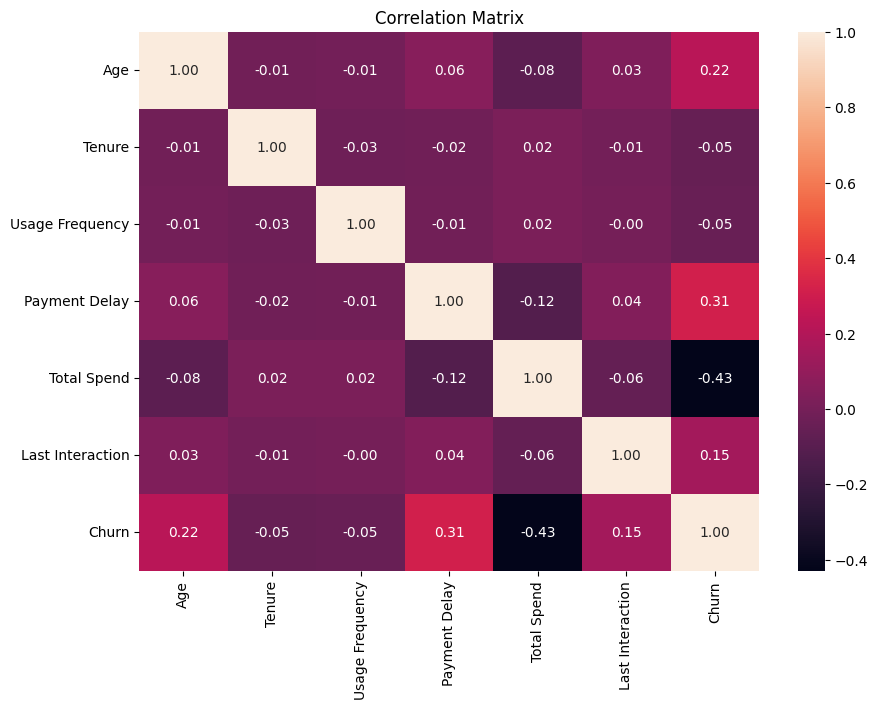

In [ ]:
corr = df[num_cols + ['Churn']].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

## Feature Validation: Potentially Suspicious Features

During EDA, two features — `Support Calls` and `Contract Length` — showed unusually strong relationships with `Churn`, including perfect separation for certain values/categories.

Rather than removing these features solely because of their strong predictive relationship with the target, their definitions and temporal availability should be investigated to assess the possibility of target leakage or synthetic/rule-based relationships.

To evaluate their impact on model performance, two modeling scenarios will be compared:

1. **Model with the potentially suspicious features**
   - Includes `Support Calls` and `Contract Length`.

2. **Model without the potentially suspicious features**
   - Excludes `Support Calls` and `Contract Length`.

The performance of both approaches will be compared using appropriate evaluation metrics. The final feature set will be selected based not only on predictive performance but also on whether the features represent information that would realistically be available before a customer churns.

# Machine Learning Pipeline

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve, average_precision_score
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
!pip install catboost xgboost lightgbm
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [ ]:
X = df.drop(columns=['Churn', 'CustomerID'])
y = df['Churn']

X.shape

(440832, 10)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.20,random_state=42,stratify=y)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (352665, 10)
X_test : (88167, 10)


In [ ]:
num_cols = [
    'Age',
    'Tenure',
    'Usage Frequency',
    'Support Calls',
    'Payment Delay',
    'Total Spend',
    'Last Interaction'
]

cat_cols = [
    'Gender',
    'Subscription Type',
    'Contract Length'
]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            num_cols
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            cat_cols
        )
    ]
)

## ML models

### 1. Logistic Regression

In [ ]:
lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

### 2. DecisionTree

In [ ]:
dt = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        random_state=42
    ))
])

### 3. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

### 4. XGBoost

In [ ]:
xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    ))
])

### 5. CatBoost

In [ ]:
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

cat_features = [
    'Gender',
    'Subscription Type',
    'Contract Length'
]

for col in cat_features:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

In [ ]:
catboost_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=False,
    thread_count=-1
)

catboost_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_features
)

CatBoostClassifier(depth=6, eval_metric='AUC', iterations=200, learning_rate=0.1, loss_function='Logloss', random_seed=42, verbose=False)

### 6. LightGBM

In [ ]:
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

for col in cat_cols:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')

In [ ]:
lightgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=-1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lightgbm_model.fit(
    X_train_lgb,
    y_train,
    categorical_feature=cat_cols
)

LGBMClassifier(n_estimators=200, n_jobs=-1, random_state=42, verbosity=-1)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]

    else:
        y_score = model.decision_function(X_test)

    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_score)
    }

    return results

In [ ]:
models = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'XGBoost': xgb
}

In [ ]:
results = []

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    result = evaluate_model(
        model,
        X_test,
        y_test,
        name
    )

    results.append(result)

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...


In [ ]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    'ROC-AUC',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,XGBoost,0.999921,1.000000,0.99986,0.999930,1.000000
2,Random Forest,0.999297,0.999940,0.99882,0.999380,0.999999
1,Decision Tree,0.999909,0.999940,0.99990,0.999920,0.999911
0,Logistic Regression,0.893373,0.923356,0.88548,0.904021,0.959026


In [ ]:
catboost_pred = catboost_model.predict(X_test_cb)

catboost_prob = catboost_model.predict_proba(
    X_test_cb
)[:, 1]

catboost_result = {
    'Model': 'CatBoost',
    'Accuracy': accuracy_score(
        y_test,
        catboost_pred
    ),
    'Precision': precision_score(
        y_test,
        catboost_pred
    ),
    'Recall': recall_score(
        y_test,
        catboost_pred
    ),
    'F1': f1_score(
        y_test,
        catboost_pred
    ),
    'ROC-AUC': roc_auc_score(
        y_test,
        catboost_prob
    )
}

results.append(catboost_result)

In [ ]:
lgb_pred = lightgbm_model.predict(X_test_lgb)

lgb_prob = lightgbm_model.predict_proba(
    X_test_lgb
)[:, 1]

lgb_result = {
    'Model': 'LightGBM',
    'Accuracy': accuracy_score(
        y_test,
        lgb_pred
    ),
    'Precision': precision_score(
        y_test,
        lgb_pred
    ),
    'Recall': recall_score(
        y_test,
        lgb_pred
    ),
    'F1': f1_score(
        y_test,
        lgb_pred
    ),
    'ROC-AUC': roc_auc_score(
        y_test,
        lgb_prob
    )
}

results.append(lgb_result)

In [ ]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    'ROC-AUC',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,XGBoost,0.999921,1.000000,0.99986,0.999930,1.000000
4,CatBoost,0.999807,1.000000,0.99966,0.999830,1.000000
5,LightGBM,0.999773,0.999960,0.99964,0.999800,1.000000
2,Random Forest,0.999297,0.999940,0.99882,0.999380,0.999999
1,Decision Tree,0.999909,0.999940,0.99990,0.999920,0.999911
0,Logistic Regression,0.893373,0.923356,0.88548,0.904021,0.959026


### **Baseline modeling revealed unusually high predictive performance across tree-based models, with XGBoost, CatBoost, and LightGBM achieving ROC-AUC values of approximately 1.00. Because several independent model families achieved near-perfect performance, this result warrants further investigation rather than being interpreted immediately as excellent generalization. Earlier EDA had already identified Support Calls and Contract Length as suspicious features due to their unusually strong relationship with Churn.**

### Now I will evaluate model performance after removing these suspicious features and compare the results with the full-feature models

In [ ]:
suspicious_cols = ['Support Calls', 'Contract Length']

X = df.drop(
    columns=['Churn', 'CustomerID'] + suspicious_cols
)

y = df['Churn']

print("Features used:")
print(X.columns.tolist())

Features used:
['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Payment Delay', 'Subscription Type', 'Total Spend', 'Last Interaction']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (352665, 8)
X_test : (88167, 8)


In [ ]:
num_cols_without = [
    'Age',
    'Tenure',
    'Usage Frequency',
    'Payment Delay',
    'Total Spend',
    'Last Interaction'
]

cat_cols_without = [
    'Gender',
    'Subscription Type'
]

In [ ]:
preprocessor_without = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_without),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_without)
    ]
)

In [ ]:
models_without = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    'XGBoost': XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    )
}

In [ ]:
pipelines_without = {}

for name, model in models_without.items():

    pipelines_without[name] = Pipeline([
        ('preprocessor', preprocessor_without),
        ('model', model)
    ])

In [ ]:
results_without = []

for name, pipeline in pipelines_without.items():

    print(f"Training {name}...")

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline, 'predict_proba'):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_score = pipeline.decision_function(X_test)

    results_without.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_score)
    })

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...


In [ ]:
results_without_df = pd.DataFrame(results_without)

results_without_df.sort_values(
    'ROC-AUC',
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.920662,0.999977,0.86012,0.924791,0.942527
1,Random Forest,0.920855,0.999049,0.86126,0.925052,0.937680
2,Decision Tree,0.860719,0.868777,0.88862,0.878587,0.856394
3,Logistic Regression,0.751789,0.779617,0.78392,0.781762,0.838304


In [ ]:
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

cat_cols_cb = [
    'Gender',
    'Subscription Type'
]

for col in cat_cols_cb:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

catboost_without = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=False,
    thread_count=-1
)

catboost_without.fit(
    X_train_cb,
    y_train,
    cat_features=cat_cols_cb
)

cb_pred = catboost_without.predict(X_test_cb)
cb_prob = catboost_without.predict_proba(X_test_cb)[:, 1]

In [ ]:
results_without.append({
    'Model': 'CatBoost',
    'Accuracy': accuracy_score(y_test, cb_pred),
    'Precision': precision_score(y_test, cb_pred),
    'Recall': recall_score(y_test, cb_pred),
    'F1': f1_score(y_test, cb_pred),
    'ROC-AUC': roc_auc_score(y_test, cb_prob)
})

In [ ]:
results_without.append({
    'Model': 'CatBoost',
    'Accuracy': accuracy_score(y_test, cb_pred),
    'Precision': precision_score(y_test, cb_pred),
    'Recall': recall_score(y_test, cb_pred),
    'F1': f1_score(y_test, cb_pred),
    'ROC-AUC': roc_auc_score(y_test, cb_prob)
})

In [ ]:
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

for col in ['Gender', 'Subscription Type']:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')

lightgbm_without = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lightgbm_without.fit(
    X_train_lgb,
    y_train,
    categorical_feature=['Gender', 'Subscription Type']
)

lgb_pred = lightgbm_without.predict(X_test_lgb)
lgb_prob = lightgbm_without.predict_proba(X_test_lgb)[:, 1]

In [ ]:
results_without.append({
    'Model': 'LightGBM',
    'Accuracy': accuracy_score(y_test, lgb_pred),
    'Precision': precision_score(y_test, lgb_pred),
    'Recall': recall_score(y_test, lgb_pred),
    'F1': f1_score(y_test, lgb_pred),
    'ROC-AUC': roc_auc_score(y_test, lgb_prob)
})

## Final result

In [ ]:
results_without_df = pd.DataFrame(results_without).drop_duplicates()

results_without_df.sort_values(
    'ROC-AUC',
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,LightGBM,0.920367,0.999767,0.85978,0.924505,0.942870
1,CatBoost,0.920492,0.999535,0.86020,0.924648,0.942819
2,XGBoost,0.920662,0.999977,0.86012,0.924791,0.942527
3,Random Forest,0.920855,0.999049,0.86126,0.925052,0.937680
4,Decision Tree,0.860719,0.868777,0.88862,0.878587,0.856394
5,Logistic Regression,0.751789,0.779617,0.78392,0.781762,0.838304


## Plotting curve of these results

In [ ]:
y_scores_without = {}

for name, pipeline in pipelines_without.items():

    if hasattr(pipeline, 'predict_proba'):
        y_scores_without[name] = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_scores_without[name] = pipeline.decision_function(X_test)

# Add CatBoost and LightGBM
y_scores_without['CatBoost'] = cb_prob
y_scores_without['LightGBM'] = lgb_prob

In [ ]:
y_scores_without

{'Logistic Regression': array([0.99287911, 0.18699342, 0.43770455, ..., 0.18511904, 0.66040176,
        0.26402595]),
 'Decision Tree': array([1., 0., 0., ..., 0., 0., 0.]),
 'Random Forest': array([1.   , 0.215, 0.1  , ..., 0.1  , 0.06 , 0.25 ]),
 'XGBoost': array([0.999997  , 0.20987563, 0.09736079, ..., 0.2100753 , 0.12312646,
        0.20775531], dtype=float32),
 'CatBoost': array([0.99999577, 0.19163862, 0.11753263, ..., 0.21209744, 0.10676477,
        0.19243438]),
 'LightGBM': array([0.99999315, 0.20101591, 0.08357982, ..., 0.20720218, 0.11461003,
        0.20352517])}

### 1. ROC-AUC curve

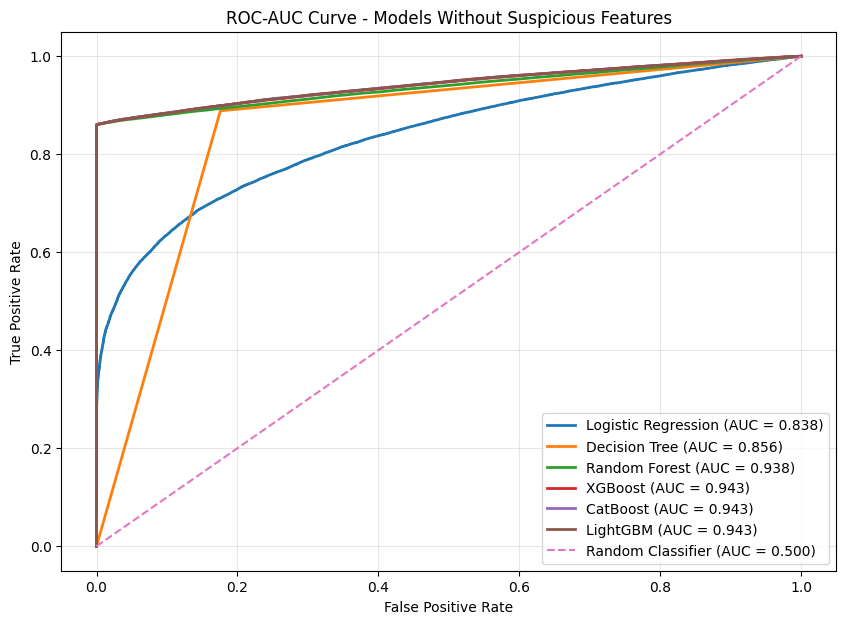

In [ ]:
plt.figure(figsize=(10, 7))

for name, y_score in y_scores_without.items():

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = roc_auc_score(y_test, y_score)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{name} (AUC = {auc_score:.3f})'
    )

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1.5,
    label='Random Classifier (AUC = 0.500)'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve - Models Without Suspicious Features')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 2. Precision-Recall curve

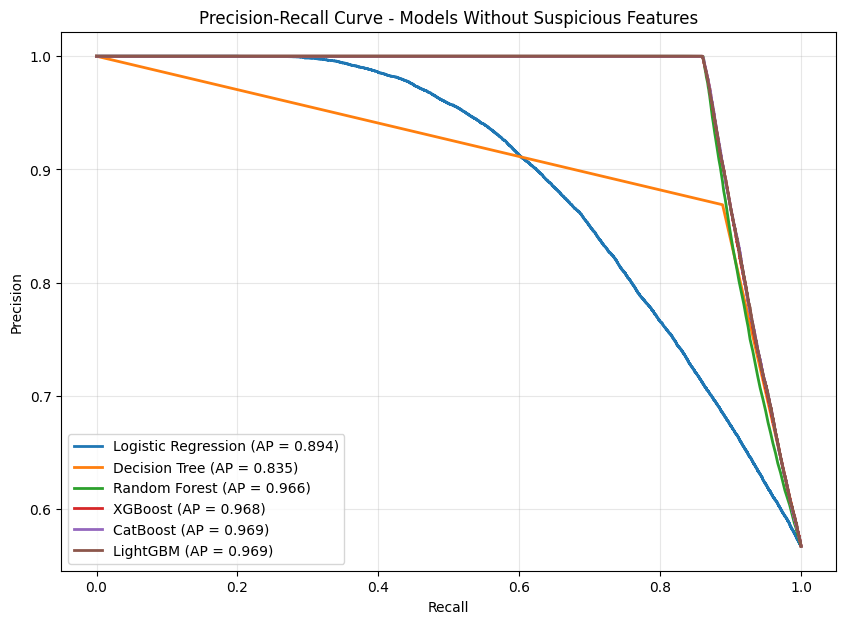

In [ ]:
plt.figure(figsize=(10, 7))

for name, y_score in y_scores_without.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_score
    )

    ap_score = average_precision_score(
        y_test,
        y_score
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f'{name} (AP = {ap_score:.3f})'
    )

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Models Without Suspicious Features')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Suspicious Feature Investigation

Initial modeling with all available features produced near-perfect performance for tree-based models, with XGBoost, CatBoost, and LightGBM achieving ROC-AUC values of approximately 1.00.

Because `Support Calls` and `Contract Length` had previously shown unusually strong relationships with Churn, both features were removed and the models were retrained.

After removing these features, performance decreased substantially. For example, XGBoost ROC-AUC decreased from 1.0000 to 0.9425, while CatBoost decreased from 1.0000 to 0.9428 and LightGBM decreased from 1.0000 to 0.9429.

This indicates that `Support Calls` and `Contract Length` contribute substantial predictive information. However, their removal did not eliminate the strong predictive performance of the boosting models, which continued to achieve ROC-AUC values around 0.94.

Therefore, the near-perfect performance cannot be attributed solely to these two features. Further investigation of the remaining variables and their interactions is required before drawing conclusions about data leakage or selecting the final feature set.

## Model Optimization Strategy

Hyperparameter tuning was considered for the top-performing models. However,
due to the large dataset size (440,833 observations) and the computational
cost of exhaustive hyperparameter searches, hyperparameter tuning was not
performed in this analysis.

Instead, the focus is on comparing multiple classification algorithms using
their baseline configurations and evaluating their performance using
Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Hyperparameter optimization is considered as a potential area for future work.

# Business Insights

The analysis suggests several customer characteristics that may be useful
for identifying customers at higher risk of churn.

### 1. Customer Support Activity

Support Calls showed a strong relationship with churn during EDA. Customers
with a higher number of support calls had substantially higher observed churn
rates.

However, this relationship should not automatically be interpreted as
support calls causing churn. High support activity may instead indicate
underlying dissatisfaction or unresolved problems.

Therefore, support activity could be considered as an early-warning signal
for customer retention teams.

### 2. Payment Behavior

Payment Delay showed a positive relationship with churn, suggesting that
customers experiencing greater payment delays may represent a higher-risk
segment.

### 3. Customer Spending

Total Spend showed a negative relationship with churn. Lower-spending
customers tended to have higher churn risk in the observed dataset.

### 4. Gender

Female customers showed a higher observed churn rate than male customers.
This association should be investigated further before being used directly
for business decisions, particularly because demographic variables require
careful interpretation.

### 5. Contract Length

Contract Length showed an unusually strong relationship with churn, including
100% observed churn among Monthly customers.

Because this is an unusually strong pattern, the feature should be validated
against the underlying business definition before being used for operational
decision-making.

# Limitations

- The dataset contains unusually strong relationships between some features
  and the churn target.
- `Support Calls` and `Contract Length` produced near-perfect predictive
  performance when included in the models.
- The underlying definitions and data-generation process of these variables
  were not available for verification.
- Therefore, near-perfect model performance should not automatically be
  interpreted as real-world predictive performance.
- Hyperparameter tuning was not performed because exhaustive searches were
  computationally expensive given the dataset size of 440,832 observations.
- External validation on an independent dataset was not performed.
- The observed relationships represent associations and should not be
  interpreted as causal relationships.

# Conclusion

This project analyzed customer churn using data cleaning, exploratory data
analysis, statistical testing, correlation analysis, and multiple machine
learning classification models.

The initial models produced unusually high performance, with XGBoost,
CatBoost, and LightGBM achieving ROC-AUC values close to 1.00 when all
features were included.

Further investigation identified `Support Calls` and `Contract Length` as
suspicious features because of their unusually strong relationships with
the churn target. After removing these features, model performance decreased
substantially but remained strong, with the best boosting models achieving
approximately 0.94 ROC-AUC.

This comparison demonstrates why model performance should be investigated
rather than evaluated solely by a high accuracy or ROC-AUC score.

The final results suggest that customer payment behavior, spending patterns,
customer characteristics, and other behavioral variables contain meaningful
information for predicting churn. However, the suspicious features and the
overall data-generating process should be validated before deploying such a
model in a real-world business environment.

Future work could include hyperparameter optimization, external validation,
investigation of the data-generation process, and testing the model on a
genuinely independent customer dataset.

## 15. Future Work

Several areas can be explored to further improve this customer churn
prediction project:

- **Hyperparameter Optimization:** Perform systematic hyperparameter tuning
  using methods such as GridSearchCV, RandomizedSearchCV, or Bayesian
  optimization for the top-performing models.

- **External Validation:** Evaluate the selected model on an independent
  dataset to determine whether its performance generalizes beyond the
  current dataset.

- **Suspicious Feature Investigation:** Further investigate the underlying
  definitions and data-generation process of `Support Calls` and
  `Contract Length`, particularly their unusually strong relationships with
  churn.

- **Feature Engineering:** Create additional behavioral features that may
  provide useful information about customer engagement, payment behavior,
  and customer support activity.

- **Model Interpretability:** Apply advanced interpretation techniques such
  as SHAP to better understand individual predictions and overall feature
  contributions.

- **Business Validation:** Validate the model's predictions with real-world
  customer retention data and determine appropriate intervention strategies
  for high-risk customers.

- **Model Deployment:** Develop a production-ready application or API that
  can provide churn-risk predictions for new customers.